# Cleaning and Forming Datasets

In this notebook, we perform some data cleaning. We first extract only Djokovic's matches from the data. We then drop rows with missing/incomplete values and finally drop non-useful columns.

## 1. Djokovic Match Extraction

We begin by extracting all of Djokovic's matches from the dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Reading dataset
df = pd.read_csv("../Data/atp_tennis.csv")

In [3]:
# Extracting only matches that Djokovic played in
df_true = df[(df["Player_1"] == "Djokovic N.") | (df["Player_2"] == "Djokovic N.")]

In [4]:
df_true.head()

,Tournament,Date,Series,Court,Surface,Round,Best of,Player_1,Player_2,Winner,Rank_1,Rank_2,Pts_1,Pts_2,Odd_1,Odd_2,Score
13063,Croatia Open,2004-07-20,International,Outdoor,Clay,1st Round,3,Djokovic N.,Volandri F.,Volandri F.,368,65,-1,-1,5.50,1.12,6-7 1-6
13511,Open Romania,2004-09-14,International,Outdoor,Clay,1st Round,3,Clement A.,Djokovic N.,Djokovic N.,67,272,-1,-1,1.53,2.35,6-2 4-6 4-6
13557,Open Romania,2004-09-16,International,Outdoor,Clay,2nd Round,3,Ferrer D.,Djokovic N.,Ferrer D.,54,272,-1,-1,1.28,3.50,4-6 6-4 6-4
13615,Thailand Open,2004-09-28,International,Indoor,Hard,1st Round,3,van Scheppingen D.,Djokovic N.,van Scheppingen D.,81,248,-1,-1,1.61,2.20,4-6 7-5 6-4
14183,Australian Open,2005-01-17,Grand Slam,Outdoor,Hard,1st Round,5,Djokovic N.,Safin M.,Safin M.,188,4,-1,-1,7.50,1.07,0-6 2-6 1-6


In [5]:
# Checking whether every row is a match with Djokovic
has_dj = (df_true[["Player_1", "Player_2"]] == "Djokovic N.").any(axis=1)
print(has_dj.all())

True


In [6]:
print(f"Shape of dataset {df_true.shape}")

Shape of dataset (1278, 17)


In [7]:
df_true.info()

<class 'pandas.DataFrame'>
Index: 1278 entries, 13063 to 68218
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Tournament  1278 non-null   str    
 1   Date        1278 non-null   str    
 2   Series      1278 non-null   str    
 3   Court       1278 non-null   str    
 4   Surface     1278 non-null   str    
 5   Round       1278 non-null   str    
 6   Best of     1278 non-null   int64  
 7   Player_1    1278 non-null   str    
 8   Player_2    1278 non-null   str    
 9   Winner      1278 non-null   str    
 10  Rank_1      1278 non-null   int64  
 11  Rank_2      1278 non-null   int64  
 12  Pts_1       1278 non-null   int64  
 13  Pts_2       1278 non-null   int64  
 14  Odd_1       1278 non-null   float64
 15  Odd_2       1278 non-null   float64
 16  Score       1278 non-null   str    
dtypes: float64(2), int64(5), str(10)
memory usage: 179.7 KB


In [8]:
df_true.describe().round(2)

,Best of,Rank_1,Rank_2,Pts_1,Pts_2,Odd_1,Odd_2
count,1278.00,1278.00,1278.00,1278.00,1278.00,1278.00,1278.00
mean,3.70,28.17,27.37,5334.17,5668.47,5.63,5.09
std,0.95,48.82,69.15,4654.03,4739.34,7.70,7.12
min,3.00,1.00,1.00,-1.00,-1.00,1.00,0.97
25%,3.00,2.00,2.00,1110.00,1285.25,1.12,1.10
50%,3.00,7.00,5.00,3950.00,4365.00,2.34,1.57
75%,5.00,36.00,29.00,9233.75,9860.00,7.00,6.00
max,5.00,589.00,1543.00,16950.00,16950.00,67.00,51.00


## 2. Missing / Duplicate / Incorrect Values

Now that we have correctly extracted all of Djokovic's matches to form our Djokovic-only dataset, let us analyse the dataset for inconsistent datapoints.

In [9]:
# NULL values
print("NULL values per column:")
df_true.isna().sum()

NULL values per column:


Tournament    0
Date          0
Series        0
Court         0
Surface       0
Round         0
Best of       0
Player_1      0
Player_2      0
Winner        0
Rank_1        0
Rank_2        0
Pts_1         0
Pts_2         0
Odd_1         0
Odd_2         0
Score         0
dtype: int64

In [10]:
print(f"The number of duplicate rows is {df_true.duplicated().sum()}")

The number of duplicate rows is 0


We notice that there are no NULL entries in any of the columns. However, from inspection we see that the columns Pts_1 and Pts_2 have many $-1$ values. These columns are meant to indicate the ATP ranking points of the two players before the match was played. $-1$ must be a placeholder for the fact that these were not collected for many of the matches since you can't have a negative number of points in ATP ranking. Thus, this is effectively a NULL value. We see below that there are disproportionately many such entries, compared to other values, supporting the fact that this must be a placeholder for NULL (along with the fact that $-1$ is an impossible value of ATP points to have).

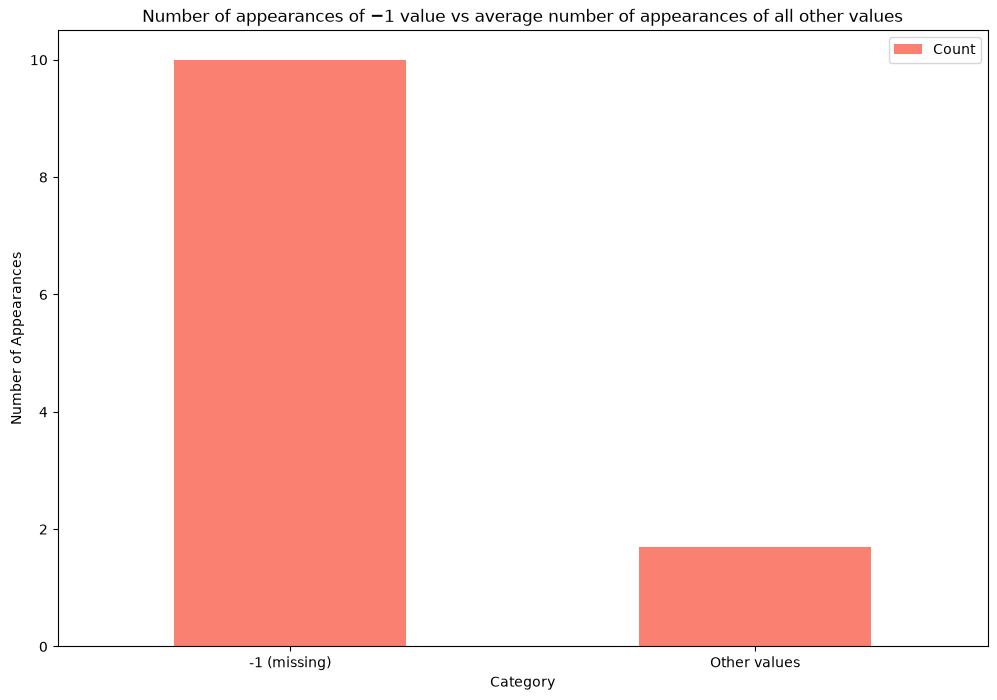

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(12,8))

# Getting columns and totals required for -1 frequency comparison
pts_1_total = df_true[["Pts_1"]].size
pts_2_total = df_true[["Pts_2"]].size

pts_1_minus = df_true[df_true["Pts_1"] == -1]["Pts_1"].size
pts_2_minus = df_true[df_true["Pts_2"] == -1]["Pts_2"].size

pts_1_not_minus = df_true[df_true["Pts_1"] != -1]["Pts_1"]
pts_2_not_minus = df_true[df_true["Pts_2"] != -1]["Pts_2"]

# Mean number of appearances of not -1 points
mean_1 = pts_1_not_minus.value_counts().mean()
mean_2 = pts_2_not_minus.value_counts().mean()

# Means across both pts_1 and pts_2
total_mean = mean_1 / 2 + mean_2 / 2
minus_1_mean = pts_1_minus / 2 + pts_2_minus / 2

plot_df = pd.DataFrame({
    'Category': ['-1 (missing)', 'Other values'],
    'Count': [minus_1_mean, total_mean]
})

plot_df.plot(kind="bar", x="Category", ax=ax, color="salmon", rot=0)
ax.set_title(r"Number of appearances of $-1$ value vs average number of appearances of all other values")
ax.set_ylabel("Number of Appearances")
plt.show()

In [12]:
# Extract all rows where either pts column entry is -1
rows = df_true[(df_true["Pts_1"] == -1) | (df_true["Pts_2"] == -1)]

# Extract all rows where neither point column has a -1 entry
rows_2 = df_true[(df_true["Pts_1"] != -1) & (df_true["Pts_2"] != -1)]

# Get the date of the last -1 row
date = rows.iloc[-1]["Date"]

# Check both at once
check_both = (rows["Date"] <= date).all() & (rows_2["Date"] > date).all()
print(f"The only Djokovic matches where ATP points were not stored are all matches before {date}: {check_both}")

The only Djokovic matches where ATP points were not stored are all matches before 2005-06-25: True


Hence, we have identified that all of the matches with dates earlier than $25/06/2005$ did not have the pre-match ATP points stored, and that all matches after this date do have legitemate point entries. This indicates that this data only began being collected in this dataset after this date.

Next, let us analyse the odds columns. Odds must be greater than $1$, otherwise it wouldn't make sense for any bookmaker to offer this as no rational person would accept odds less than $1$. Winning would mean you lose money.

In [13]:
# Checking if odds less than 1 exist
print(f"Odds less than or equal 1 exist: {(df["Odd_1"] <= 1.0).any() | (df["Odd_2"] <= 1.0).any()}")

Odds less than or equal 1 exist: True


The above indicates that there do indeed exist rows with odds entries less than $1$. Let us work out how many of these exist.

In [14]:
# Extract number of "bad" odds rows
bad_rows = df_true[(df_true["Odd_1"] <= 1.0) | (df_true["Odd_2"] <= 1.0)]
bad_rows_num = bad_rows.shape[0]

# Extract total number of rows
total_size = df_true.shape[0]

# Calculate percentage of bad rows
pct = bad_rows_num / total_size * 100

print("Quick Odds Analysis")
print("-"*70)
print(f"The number of rows with odds less than or equal to 1 is {bad_rows_num}")
print(f"The total number of rows is {total_size}")
print(rf"The percentage of rows with odds less than or equal to 1 is {pct :.2f}%")

Quick Odds Analysis
----------------------------------------------------------------------
The number of rows with odds less than or equal to 1 is 18
The total number of rows is 1278
The percentage of rows with odds less than or equal to 1 is 1.41%


Now that we have identified that there are rows with undesirable values, we will drop these rows as they will not be useful as predictors.

In [15]:
# Drop null pts rows and bad odds rows
indices_1 = rows.index
indices_2 = bad_rows.index
df_2 = df_true.copy().drop(index=indices_1.union(indices_2))

# Checking the new dataframe is cleaned
print(f"No points scores of -1 exist: {((df_2["Pts_1"] != -1) & (df_2["Pts_2"] != -1)).all()}")
print(f"No odds of less than 1 exist: {((df_2["Odd_1"] > 1) & (df_2["Odd_2"] > 1)).all()}")

print(f"Total number of rows after dropping: {df_2.shape[0]}")

No points scores of -1 exist: True
No odds of less than 1 exist: True
Total number of rows after dropping: 1250


## 3. Non-Useful Columns

We also need to analyse our features to check whether there are any features we find irrelevant in our dataset. In particular, we theorise that the Tournament column will not be useful.

In [16]:
print(f"Number of unique tournament participations: {df_2["Tournament"].nunique()}")

Number of unique tournament participations: 56


In [17]:
df_2["Tournament"].value_counts()

Tournament
Wimbledon                                     115
French Open                                   106
Australian Open                               103
US Open                                        99
Internazionali BNL d'Italia                    79
Masters Cup                                    65
Monte Carlo Masters                            54
Western & Southern Financial Group Masters     53
BNP Paribas Open                               52
Dubai Tennis Championships                     51
BNP Paribas Masters                            51
Shanghai Masters                               50
Sony Ericsson Open                             49
Rogers Masters                                 43
China Open                                     29
Mutua Madrid Open                              22
Qatar Exxon Mobil Open                         18
Serbia Open                                    15
Pacific Life Open                              13
ABN AMRO World Tennis Tournament       

We will drop the tournament column. There are some tournaments where Djokovic didn't often play. Using one-hot-encoding for these columns may lead to models overfitting to correctly predict these columns, and carries a risk of perfect separation for tournaments where he played few times. Furthermore, most of the information encoded in the Tournament is redundant with the Surface, Series, Court etc.

We will also drop the Score column since we will be focused on prediction of odds and win probabilities. The match result is only known after the match is played, and would clearly already tell us our prediction result exactly, meaning we would have data leakage.

In [18]:
df_3 = df_2.copy().drop(columns=["Tournament", "Score"])

We have successfully extracted all of Djokovic's matches, and done all of the cleaning we need to do. We can now export our data.

In [19]:
# Exporting full dataset
df_3.to_csv("../Data/djokovic_data.csv", index=False)